# Section 13: Predictive Modeling (statistical models)
Trains and compares three statistical models on the modeling table built in Sections 8–12. The shallow neural network is a separate section and plugs into the same comparison (see 13.9).

| Part | What it does |
|---|---|
| 13.1 | Loads the modeling table, features and splits from the feature-engineering notebook |
| 13.2 | Metrics, primary/secondary choice, how the threshold is chosen |
| 13.3 | Baselines (no-skill, grid-only logistic regression) |
| 13.4 | The three models: how each works, limits, and why it is here |
| 13.5 | Hyperparameter search with walk-forward folds **inside train** |
| 13.6 | Initial vs tuned settings on validation, final model per family |
| 13.7 | Thresholds (validation only) and train / validation results |
| 13.8 | Unseen test results, plots, stability checks |
| 13.9 | Hand-off to ablation, XAI, inference and the neural network |

**Same rows, same features for every model.** Only the preprocessing differs, because the model families need different inputs (scaling for the linear model, none for trees).
**Test seasons stay closed** until 13.8. Hyperparameters, settings and thresholds are chosen on train and validation only.

In [1]:
# Setup: install any missing library (XGBoost is not preinstalled everywhere), then continue. Safe to re-run.
import importlib.util, subprocess, sys
for _mod, _pip in [("xgboost", "xgboost"), ("pyarrow", "pyarrow"), ("joblib", "joblib")]:
    if importlib.util.find_spec(_mod) is None:
        print(f"installing {_pip} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pip])
print("xgboost, pyarrow, joblib available")

xgboost, pyarrow, joblib available


In [2]:
import os, glob, json, math, time, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score, recall_score,
                             roc_curve, precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
SEED = 42
np.random.seed(SEED)
N_JOBS = max(1, min(os.cpu_count() or 2, 4))      # explicit thread count (n_jobs=-1 can oversubscribe shared notebook machines)
print("CPU threads used by the models:", N_JOBS)

CPU threads used by the models: 4


## 13.1 Load the modeling table, features and splits
Reads the files saved at the end of Section 12 (`modeling_table`, `feature_config.json`). On Kaggle, attach the output of the feature-engineering notebook as an input. The split column was set there (train ≤ 2019, validation 2020–21, test ≥ 2022), so the split rule is not re-decided here.

In [3]:
def find_artifacts():
    cands = [os.environ.get("F1_CLEAN_DIR", ""), "/kaggle/working/clean/", "clean/", "../clean/"]
    cands += [os.path.dirname(p) + "/" for p in glob.glob("/kaggle/input/**/feature_config.json", recursive=True)]
    for c in cands:
        if c and os.path.exists(c + "feature_config.json") and (os.path.exists(c + "modeling_table.parquet") or os.path.exists(c + "modeling_table.csv")):
            return c
    raise FileNotFoundError("feature_config.json / modeling_table not found. Run the feature-engineering notebook (Section 12 saves them) "
                            "or attach its output, or set F1_CLEAN_DIR.")

OUT = find_artifacts()
cfg = json.load(open(OUT + "feature_config.json"))
mdl = pd.read_parquet(OUT + "modeling_table.parquet") if os.path.exists(OUT + "modeling_table.parquet") else pd.read_csv(OUT + "modeling_table.csv")

TARGET, FEATURES = cfg["target"], list(cfg["features"])
BINARY, CONTINUOUS = list(cfg["binary"]), list(cfg["continuous"])
FEATURE_GROUPS = {g: list(f) for g, f in cfg["groups"].items()}
VAL_YEARS, TEST_YEARS = cfg["val_years"], cfg["test_years"]
mdl = mdl.sort_values(["race_order", "driverId"]).reset_index(drop=True)

train = mdl[mdl["split"] == "train"].copy()
val = mdl[mdl["split"] == "val"].copy()
test = mdl[mdl["split"] == "test"].copy()          # not touched until 13.8
SPLITS = {"train": train, "val": val}              # test is added to this dict only in 13.8

# structural checks
assert set(FEATURES) <= set(mdl.columns) and len(FEATURES) == len(set(FEATURES))
assert set(BINARY) | set(CONTINUOUS) == set(FEATURES)
assert not mdl.duplicated(["raceId", "driverId"]).any(), "grain broken"
assert not (set(train["raceId"]) & set(val["raceId"])) and not (set(val["raceId"]) & set(test["raceId"]))
assert train["race_order"].max() < val["race_order"].min() and val["race_order"].max() < test["race_order"].min()

print(f"Artifacts from: {OUT}")
print(f"{len(FEATURES)} features ({len(BINARY)} binary, {len(CONTINUOUS)} continuous) in groups {list(FEATURE_GROUPS)}")
summary = (mdl.groupby("split").agg(rows=(TARGET, "size"), races=("raceId", "nunique"), first=("year", "min"), last=("year", "max"),
                                    podiums=(TARGET, "sum"), podium_rate=(TARGET, "mean")).loc[["train", "val", "test"]])
display(summary.round(3))

Artifacts from: clean/
29 features (4 binary, 25 continuous) in groups ['grid', 'qualifying', 'driver_form', 'constructor_form', 'standings', 'circuit_history', 'context']


,rows,races,first,last,podiums,podium_rate
split,,,,,,
train,22441,1007,1950,2019,3021,0.135
val,774,39,2020,2021,117,0.151
test,1351,68,2022,2024,204,0.151


In [4]:
# Preprocessing from Section 11 (copied so this notebook runs on its own; same logic, fitted on training rows only)
class QuantileClipper(BaseEstimator, TransformerMixin):
    # Winsorise each column at quantiles learned on the training data (NaN stays NaN)
    def __init__(self, lower=0.01, upper=0.99): self.lower, self.upper = lower, upper
    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0); self.hi_ = np.nanquantile(X, self.upper, axis=0); return self
    def transform(self, X): return np.clip(np.asarray(X, float), self.lo_, self.hi_)

def make_preprocessor(kind="linear", continuous=None, binary=None):
    # linear: impute(+missing indicator) -> clip -> scale | tree: impute(+indicator) | native: pass through, NaN handled by the model
    continuous = CONTINUOUS if continuous is None else continuous
    binary = BINARY if binary is None else binary
    if kind == "native":
        return ColumnTransformer([("all", "passthrough", continuous + binary)], verbose_feature_names_out=False)
    imp = lambda: SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)
    cont = [("imp", imp())] + ([("clip", QuantileClipper()), ("sc", StandardScaler())] if kind == "linear" else [])
    return ColumnTransformer([("cont", Pipeline(cont), continuous),
                              ("bin", SimpleImputer(strategy="most_frequent", keep_empty_features=True), binary)])

def season_walk_forward(d, n_folds=3):
    # expanding-window folds: train on seasons < s, validate on season s
    yrs = sorted(d["year"].unique())[-n_folds:]
    return [(d.index[d["year"] < s], d.index[d["year"] == s]) for s in yrs]

def assert_no_test(*frames):
    for f in frames:
        assert "test" not in set(f["split"]), "test rows leaked into a model-selection step"

## 13.2 Metrics and how they are used
| Metric | Role here |
|---|---|
| **PR-AUC** | **Primary.** Only about 15% of rows are podiums (3 of ~20 starters), and PR-AUC only rewards ranking the true podium drivers above the rest. It does not depend on a threshold. |
| **ROC-AUC** | **Secondary.** Threshold-free and easy to compare, but the many easy negatives (back of the grid) make it look high even for weak models. |
| **F1** | Reported at one threshold per model. It depends on that threshold, so it is not used to pick models. |
| Precision / recall | Reported next to F1 to show what the threshold trades off. |
| Top-3 precision per race | Extra, race-aware: of the 3 drivers the model ranks highest in a race, how many really podiumed. |

**Threshold rule.** For each model, the F1-optimal threshold is searched on **validation** predictions (the model was fitted on train only) and then frozen for train and test. Training predictions are not used to choose it because flexible models are over-confident on rows they have seen.

**Uncertainty.** Validation is two seasons and test is three, so differences are small relative to noise. A race-level bootstrap (resample whole races) gives a 95% interval for PR-AUC. Only trust gaps that are clearly outside it.

In [5]:
def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    return float(thr[int(np.nanargmax(f1[:-1]))])

def metrics_at(d, p, thr):
    y = d[TARGET].to_numpy(); p = np.asarray(p, float); pred = (p >= thr).astype(int)
    top3 = d.assign(_p=p).sort_values(["raceId", "_p"], ascending=[True, False]).groupby("raceId").head(3)
    return dict(roc_auc=roc_auc_score(y, p), pr_auc=average_precision_score(y, p), f1=f1_score(y, pred, zero_division=0),
                precision=precision_score(y, pred, zero_division=0), recall=recall_score(y, pred, zero_division=0),
                top3_precision=top3[TARGET].mean())

def pr_auc_ci(d, p, n_boot=300, seed=SEED):
    # bootstrap over RACES (rows in a race are not independent)
    rng = np.random.default_rng(seed); p = np.asarray(p, float)
    y = d[TARGET].to_numpy(); race = d["raceId"].to_numpy()
    idx_by_race = pd.Series(np.arange(len(d))).groupby(race).apply(lambda s: s.to_numpy()).tolist()
    vals = []
    for _ in range(n_boot):
        pick = np.concatenate([idx_by_race[i] for i in rng.integers(0, len(idx_by_race), len(idx_by_race))])
        vals.append(average_precision_score(y[pick], p[pick]))
    return tuple(np.percentile(vals, [2.5, 97.5]))

## 13.3 Baselines
A baseline is the simplest reasonable reference, so we can tell whether a bigger model earns its complexity.
- **No-skill:** predict the same probability for everyone. PR-AUC then equals the podium rate.
- **Grid-only logistic regression:** the starting slot alone, the strongest single pre-race signal found in Section 10.1. This is the statistical-model baseline every full model must beat.
Both are reference rows, not part of the three-model comparison (they use one feature, the models use all of them).

In [6]:
def fit_predict_grid_baseline(fit_df, *eval_dfs):
    m = LogisticRegression(max_iter=2000, class_weight="balanced").fit(fit_df[["grid_clean"]].fillna(fit_df["grid_clean"].median()), fit_df[TARGET])
    med = fit_df["grid_clean"].median()
    return [m.predict_proba(d[["grid_clean"]].fillna(med))[:, 1] for d in eval_dfs]

p_tr_b, p_va_b = fit_predict_grid_baseline(train, train, val)
thr_base = best_f1_threshold(val[TARGET], p_va_b)
base_rows = {"no-skill (prevalence)": dict(roc_auc=0.5, pr_auc=val[TARGET].mean(), f1=np.nan, precision=np.nan, recall=np.nan, top3_precision=np.nan),
             "grid-only LR": metrics_at(val, p_va_b, thr_base)}
base_val = pd.DataFrame(base_rows).T
print("Baselines on validation (threshold for grid-only LR chosen on validation):")
display(base_val.round(4))

Baselines on validation (threshold for grid-only LR chosen on validation):


,roc_auc,pr_auc,f1,precision,recall,top3_precision
no-skill (prevalence),0.5000,0.1512,NaN,NaN,NaN,NaN
grid-only LR,0.9101,0.6478,0.6953,0.6983,0.6923,0.7009


## 13.4 The three models
All three give a podium probability per driver-race. Preprocessing follows Section 11: `linear` for logistic regression (impute + missing flags, clip, scale), `tree` for random forest (impute + missing flags), `native` for XGBoost (it handles missing values itself).

**1. Logistic regression (linear baseline family).**
*How it works:* a weighted sum of the standardised features is squashed to a 0–1 probability; weights are fitted by minimising log-loss with an L2 penalty (`C` controls its strength).
*Why here:* transparent, hard to overfit, and the reference every other model must beat. Class weights are balanced because podiums are rare.
*Limits:* only straight-line effects in the features (grid 1→2 is treated like grid 15→16 in log-odds), no automatic interactions (e.g. a strong car matters more from the front), sensitive to scaling and outliers.

**2. XGBoost (gradient boosting, sequential trees).**
*How it works:* many small trees added one at a time, each fitted to the mistakes (gradient of the loss) of the trees before it; learning rate, depth and regularisation keep it from memorising.
*Why here:* strong on tabular data, captures non-linear effects and interactions, handles missing values natively (useful: qualifying data is missing for early eras).
*Limits:* more hyperparameters, can overfit a small training set, probabilities are not always well calibrated, and it extrapolates poorly to a new regulation era.

**3. Random forest (bagging, parallel trees) — the extra model.**
*How it works:* hundreds of deep trees, each fitted on a bootstrap sample with a random subset of features at each split, then averaged.
*Why this one:* it reduces **variance** by averaging independent trees, while XGBoost reduces **bias** by boosting. That makes it a real alternative to boosting and a different idea from logistic regression. It also handles non-linearity and needs little tuning, so it is a fair check that gains are not just from boosting.
*Limits:* predictions are piecewise-constant and averaged, so probabilities are compressed toward the middle; large models; no extrapolation beyond the training range.

In [7]:
# Initial settings: sensible starting points chosen BEFORE tuning (not the libraries' defaults), shown as the "initial" attempt
INITIAL = {
    "lr":  dict(C=1.0),
    "rf":  dict(n_estimators=300, max_depth=8, min_samples_leaf=20, max_features="sqrt"),
    "xgb": dict(n_estimators=300, learning_rate=0.05, max_depth=4, min_child_weight=5, subsample=0.8, colsample_bytree=0.8),
}
NAMES = {"lr": "Logistic regression", "xgb": "XGBoost", "rf": "Random forest"}
PREP = {"lr": "linear", "rf": "tree", "xgb": "native"}

def build(kind, **params):
    p = {**INITIAL[kind], **params}
    if kind == "lr":
        est = LogisticRegression(class_weight="balanced", max_iter=5000, **p)
    elif kind == "rf":
        est = RandomForestClassifier(class_weight="balanced_subsample", n_jobs=N_JOBS, random_state=SEED, **p)
    else:
        est = XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=N_JOBS, random_state=SEED, verbosity=0, **p)
    return Pipeline([("pre", make_preprocessor(PREP[kind])), ("clf", est)])

def proba(model, d): return model.predict_proba(d[FEATURES])[:, 1]

# smoke test: every model fits and predicts on the same rows/features
FIT_TIME = {}
for k in NAMES:
    t0 = time.time(); m = build(k).fit(train[FEATURES], train[TARGET]); FIT_TIME[k] = time.time() - t0
    print(f"{NAMES[k]:20s} fit {FIT_TIME[k]:5.1f}s | {len(FEATURES)} features -> {m.named_steps['pre'].transform(train[FEATURES].head(3)).shape[1]} model inputs")

Logistic regression  fit   0.3s | 29 features -> 43 model inputs
XGBoost              fit   1.2s | 29 features -> 29 model inputs
Random forest        fit   4.4s | 29 features -> 43 model inputs


## 13.5 Hyperparameter search (train only)
Each setting is scored on the **walk-forward folds inside train**: fit on all seasons before season *s*, score PR-AUC on season *s*, for the last three training seasons. This respects time order (a shuffled k-fold would let a model see the future). The preprocessor is refitted inside every fold. Validation and test seasons are not used here.
Grids are small on purpose: the training set is a few thousand rows, and a large search would mostly fit noise in three folds. The setting with the best mean fold PR-AUC wins; the full trial tables are kept below as the record of attempts.

In [8]:
GRIDS = {
    "lr":  dict(C=[0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]),
    "rf":  dict(max_depth=[4, 8], min_samples_leaf=[10, 30, 60], max_features=["sqrt", 0.5]),
    "xgb": dict(max_depth=[2, 3, 4], learning_rate=[0.03, 0.08], n_estimators=[150, 300], min_child_weight=[5, 20]),
}
FIXED = {"rf": dict(n_estimators=150)}      # fewer trees while searching only
n_set = {k: int(np.prod([len(v) for v in g.values()])) for k, g in GRIDS.items()}
est = sum(FIT_TIME[k] * n_set[k] * 3 * (0.5 if k in FIXED else 1) for k in GRIDS)
print(f"Settings to try: {n_set} x 3 folds. Rough time estimate: {est/60:.1f} min (from the fit times above; progress is printed below).")
folds = season_walk_forward(train, n_folds=3)
for i, (a, b) in enumerate(folds):
    print(f"fold {i}: fit on {len(a):,} rows (seasons < {int(train.loc[b, 'year'].iloc[0])}) -> score season {int(train.loc[b, 'year'].iloc[0])} ({len(b)} rows)")

def cv_pr_auc(kind, params):
    assert_no_test(train)
    s = []
    for a_idx, b_idx in folds:
        a, b = train.loc[a_idx], train.loc[b_idx]
        s.append(average_precision_score(b[TARGET], proba(build(kind, **params).fit(a[FEATURES], a[TARGET]), b)))
    return float(np.mean(s)), float(np.std(s))

TRIALS, BEST_PARAMS = {}, {}
for kind, grid in GRIDS.items():
    t0 = time.time(); rows, plist = [], []
    for combo in itertools.product(*grid.values()):
        params = dict(zip(grid, combo)); m, sd = cv_pr_auc(kind, {**FIXED.get(kind, {}), **params})
        rows.append(dict(**params, cv_pr_auc=m, cv_std=sd)); plist.append(params)
        print(f"\r  {NAMES[kind]}: {len(rows)}/{n_set[kind]} settings, {time.time()-t0:.0f}s elapsed", end="", flush=True)
    print()
    TRIALS[kind] = pd.DataFrame(rows).sort_values("cv_pr_auc", ascending=False)
    BEST_PARAMS[kind] = {**FIXED.get(kind, {}), **plist[int(TRIALS[kind].index[0])]}            # original dict: keeps int/float/str types
    TRIALS[kind] = TRIALS[kind].reset_index(drop=True)
    best = TRIALS[kind].iloc[0]
    print(f"{NAMES[kind]:20s} {len(rows):3d} settings in {time.time()-t0:5.1f}s | best CV PR-AUC {best['cv_pr_auc']:.4f} (+/- {best['cv_std']:.4f}) with {BEST_PARAMS[kind]}")

Settings to try: {'lr': 7, 'rf': 12, 'xgb': 24} x 3 folds. Rough time estimate: 2.9 min (from the fit times above; progress is printed below).
fold 0: fit on 21,203 rows (seasons < 2017) -> score season 2017 (399 rows)
fold 1: fit on 21,602 rows (seasons < 2018) -> score season 2018 (420 rows)
fold 2: fit on 22,022 rows (seasons < 2019) -> score season 2019 (419 rows)
  Logistic regression: 7/7 settings, 6s elapsed
Logistic regression    7 settings in   6.0s | best CV PR-AUC 0.7088 (+/- 0.0104) with {'C': 0.003}
  Random forest: 12/12 settings, 97s elapsed
Random forest         12 settings in  96.8s | best CV PR-AUC 0.7410 (+/- 0.0290) with {'n_estimators': 150, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
  XGBoost: 24/24 settings, 39s elapsed
XGBoost               24 settings in  38.6s | best CV PR-AUC 0.7432 (+/- 0.0357) with {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 150, 'min_child_weight': 5}


--- Logistic regression: top 5 of 7 settings (mean PR-AUC over 3 walk-forward folds)


,C,cv_pr_auc,cv_std
0,0.003,0.7088,0.0104
1,0.010,0.7060,0.0122
2,0.030,0.7053,0.0159
3,0.100,0.7034,0.0163
4,0.300,0.7022,0.0176


--- Random forest: top 5 of 12 settings (mean PR-AUC over 3 walk-forward folds)


,max_depth,min_samples_leaf,max_features,cv_pr_auc,cv_std
0,8,10,sqrt,0.7410,0.0290
1,8,60,0.5,0.7407,0.0197
2,8,30,sqrt,0.7379,0.0266
3,8,60,sqrt,0.7354,0.0254
4,8,30,0.5,0.7349,0.0246


--- XGBoost: top 5 of 24 settings (mean PR-AUC over 3 walk-forward folds)


,max_depth,learning_rate,n_estimators,min_child_weight,cv_pr_auc,cv_std
0,3,0.03,150,5,0.7432,0.0357
1,2,0.08,150,20,0.7425,0.0397
2,4,0.08,150,20,0.7408,0.0200
3,4,0.03,150,20,0.7404,0.0389
4,4,0.03,150,5,0.7402,0.0350


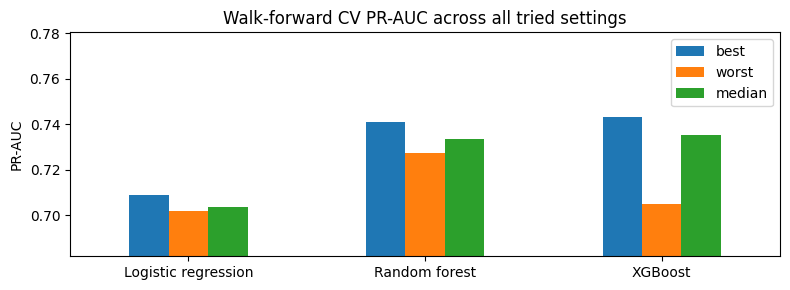

In [9]:
for kind in TRIALS:
    print(f"--- {NAMES[kind]}: top 5 of {len(TRIALS[kind])} settings (mean PR-AUC over 3 walk-forward folds)")
    display(TRIALS[kind].head(5).round(4))

# how sensitive is each model to its settings? spread between best and worst setting
spread = pd.DataFrame({NAMES[k]: dict(best=t["cv_pr_auc"].max(), worst=t["cv_pr_auc"].min(), median=t["cv_pr_auc"].median()) for k, t in TRIALS.items()}).T
ax = spread.plot(kind="bar", figsize=(8, 3), rot=0, title="Walk-forward CV PR-AUC across all tried settings"); ax.set_ylabel("PR-AUC")
ax.set_ylim(spread.min().min() - 0.02, None); plt.tight_layout(); plt.show()

## 13.6 Initial vs tuned settings (validation)
Trial and error shown side by side: every family is fitted on train twice, once with the initial settings and once with the settings chosen in 13.5, and scored on validation. The tuned setting is the final model of each family: it was picked on three walk-forward seasons of train, which is more evidence than the two validation seasons. Validation is the check that tuning did not hurt and that overfitting went down (compare the train-minus-validation gap).

,model,attempt,train_pr_auc,val_pr_auc,val_roc_auc,gap_train_minus_val
0,Logistic regression,initial,0.5716,0.7339,0.9342,-0.1623
1,Logistic regression,tuned,0.5744,0.7165,0.9312,-0.1421
2,XGBoost,initial,0.6930,0.7133,0.9308,-0.0204
3,XGBoost,tuned,0.6039,0.7171,0.9322,-0.1132
4,Random forest,initial,0.6390,0.7185,0.9304,-0.0794
5,Random forest,tuned,0.6520,0.7171,0.9301,-0.0651


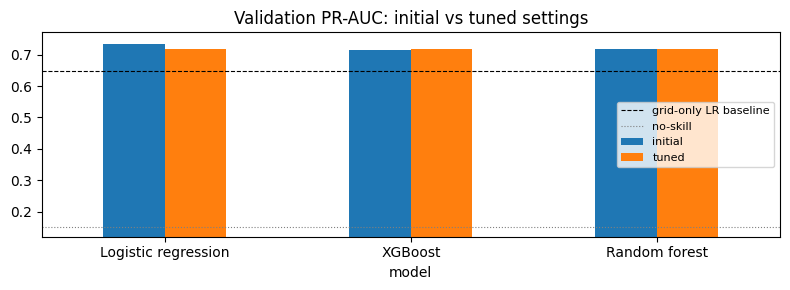

Logistic regression  tuned vs initial on validation: PR-AUC -0.0174, train-val gap +0.0202
XGBoost              tuned vs initial on validation: PR-AUC +0.0038, train-val gap -0.0929
Random forest        tuned vs initial on validation: PR-AUC -0.0013, train-val gap +0.0143
Final settings per family (chosen on train walk-forward CV; validation used as a check): {'Logistic regression': {'C': 0.003}, 'XGBoost': {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 150, 'min_child_weight': 5}, 'Random forest': {'n_estimators': 150, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}}


In [10]:
cmp_rows, fitted = [], {}
for kind in NAMES:
    for tag, params in [("initial", {}), ("tuned", BEST_PARAMS[kind])]:
        m = build(kind, **params).fit(train[FEATURES], train[TARGET]); fitted[(kind, tag)] = m
        pv, pt = proba(m, val), proba(m, train)
        cmp_rows.append(dict(model=NAMES[kind], attempt=tag, train_pr_auc=average_precision_score(train[TARGET], pt),
                             val_pr_auc=average_precision_score(val[TARGET], pv), val_roc_auc=roc_auc_score(val[TARGET], pv),
                             params={**INITIAL[kind], **params}))
attempts = pd.DataFrame(cmp_rows)
attempts["gap_train_minus_val"] = attempts["train_pr_auc"] - attempts["val_pr_auc"]
display(attempts.drop(columns="params").round(4))

pv = attempts.pivot(index="model", columns="attempt", values="val_pr_auc").loc[list(NAMES.values())]
ax = pv.plot(kind="bar", figsize=(8, 3), rot=0, title="Validation PR-AUC: initial vs tuned settings")
ax.axhline(base_val.loc["grid-only LR", "pr_auc"], color="k", ls="--", lw=0.8, label="grid-only LR baseline")
ax.axhline(val[TARGET].mean(), color="grey", ls=":", lw=0.8, label="no-skill"); ax.set_ylim(val[TARGET].mean() * 0.8, None); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

FINAL_TAG = {k: "tuned" for k in NAMES}
FINAL = {NAMES[k]: fitted[(k, FINAL_TAG[k])] for k in NAMES}                # fitted on train only
FINAL_PARAMS = {NAMES[k]: {**INITIAL[k], **(BEST_PARAMS[k] if FINAL_TAG[k] == "tuned" else {})} for k in NAMES}
for k in NAMES:
    a = attempts[attempts["model"] == NAMES[k]].set_index("attempt")
    print(f"{NAMES[k]:20s} tuned vs initial on validation: PR-AUC {a.loc['tuned','val_pr_auc'] - a.loc['initial','val_pr_auc']:+.4f}, "
          f"train-val gap {a.loc['tuned','gap_train_minus_val'] - a.loc['initial','gap_train_minus_val']:+.4f}")
print("Final settings per family (chosen on train walk-forward CV; validation used as a check):", {NAMES[k]: BEST_PARAMS[k] for k in NAMES})

## 13.7 Thresholds and train / validation results
`REGISTRY` maps a model name to a function that returns podium probabilities for a dataframe. Everything below (tables, curves) loops over it, so another model, such as the neural network, can be added with one line (see 13.9).

In [11]:
REGISTRY = {name: (lambda d, m=m: proba(m, d)) for name, m in FINAL.items()}
THRESHOLDS = {}

def score_table(splits):
    rows = []
    for name, predict in REGISTRY.items():
        for sp, d in splits.items():
            rows.append(dict(model=name, split=sp, threshold=THRESHOLDS[name], **metrics_at(d, predict(d), THRESHOLDS[name])))
    return pd.DataFrame(rows)

# threshold per model: F1-optimal on VALIDATION predictions
for name, predict in REGISTRY.items():
    THRESHOLDS[name] = best_f1_threshold(val[TARGET], predict(val))
print("F1-optimal thresholds (validation):", {k: round(v, 3) for k, v in THRESHOLDS.items()})

res_trval = score_table(SPLITS)
display(res_trval.pivot(index="model", columns="split", values=["roc_auc", "pr_auc", "f1"]).round(4).loc[list(REGISTRY)])

F1-optimal thresholds (validation): {'Logistic regression': 0.622, 'XGBoost': 0.361, 'Random forest': 0.721}


roc_auc          pr_auc              f1        
split                 train     val   train     val   train     val
model                                                              
Logistic regression  0.9022  0.9312  0.5744  0.7165  0.5760  0.7015
XGBoost              0.9104  0.9322  0.6039  0.7171  0.5897  0.7094
Random forest        0.9265  0.9301  0.6520  0.7171  0.6247  0.7119

split,train,val,gap
model,,,
Logistic regression,0.5744,0.7165,-0.1421
XGBoost,0.6039,0.7171,-0.1132
Random forest,0.6520,0.7171,-0.0651


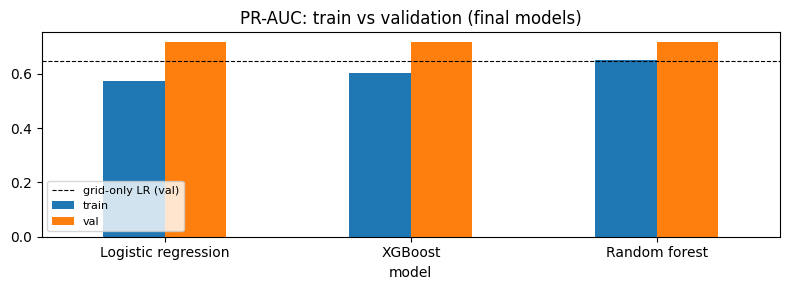

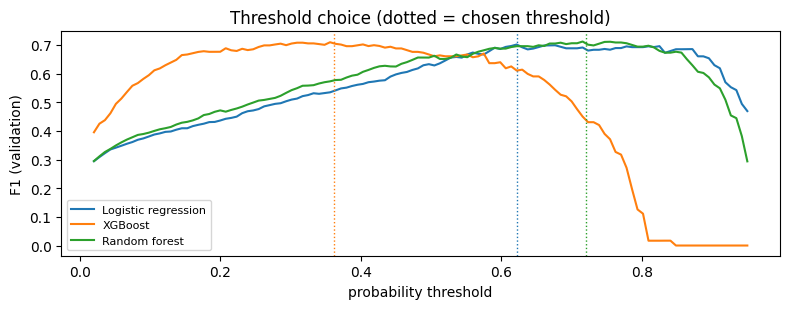

In [12]:
# overfitting check: train vs validation gap (large gap = memorising training seasons)
gap_tbl = res_trval.pivot(index="model", columns="split", values="pr_auc").loc[list(REGISTRY)]
gap_tbl["gap"] = gap_tbl["train"] - gap_tbl["val"]
display(gap_tbl.round(4))
ax = gap_tbl[["train", "val"]].plot(kind="bar", figsize=(8, 3), rot=0, title="PR-AUC: train vs validation (final models)")
ax.axhline(base_val.loc["grid-only LR", "pr_auc"], color="k", ls="--", lw=0.8, label="grid-only LR (val)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# F1 against threshold on validation: where each threshold was picked
fig, ax = plt.subplots(figsize=(8, 3.2)); ts = np.linspace(0.02, 0.95, 120)
for name, predict in REGISTRY.items():
    p = predict(val); l, = ax.plot(ts, [f1_score(val[TARGET], (p >= t).astype(int), zero_division=0) for t in ts], label=name)
    ax.axvline(THRESHOLDS[name], color=l.get_color(), ls=":", lw=1)
ax.set(xlabel="probability threshold", ylabel="F1 (validation)", title="Threshold choice (dotted = chosen threshold)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 13.8 Unseen test results
The test seasons (new ground-effect regulations) are used here for the first and only time. Models, settings and thresholds are frozen; this cell only scores them.

In [13]:
SPLITS["test"] = test
res_all = score_table(SPLITS)
test_base = metrics_at(test, fit_predict_grid_baseline(train, test)[0], thr_base)

order_models = list(REGISTRY)
full = res_all.set_index(["model", "split"])
table = pd.concat({sp: full.xs(sp, level="split")[["roc_auc", "pr_auc", "f1", "precision", "recall", "top3_precision"]].loc[order_models] for sp in ["train", "val", "test"]}, axis=1)
print("MODEL COMPARISON (threshold per model fixed on validation)")
display(table.round(4))
print("Reference: grid-only LR on test:", {k: round(v, 4) for k, v in test_base.items()}, "| no-skill PR-AUC (test prevalence):", round(test[TARGET].mean(), 4))

MODEL COMPARISON (threshold per model fixed on validation)


train                                                      val                                                     test                  \
                    roc_auc  pr_auc      f1 precision  recall top3_precision roc_auc  pr_auc      f1 precision  recall top3_precision roc_auc  pr_auc      f1   
model                                                                                                                                                           
Logistic regression  0.9022  0.5744  0.5760    0.4626  0.7630         0.5578  0.9312  0.7165  0.7015    0.6225  0.8034         0.6838  0.9365  0.7163  0.6440   
XGBoost              0.9104  0.6039  0.5897    0.5611  0.6213         0.5763  0.9322  0.7171  0.7094    0.7094  0.7094         0.7009  0.9411  0.7227  0.6844   
Random forest        0.9265  0.6520  0.6247    0.5776  0.6802         0.6018  0.9301  0.7171  0.7119    0.7059  0.7179         0.6923  0.9378  0.7165  0.6667   

                                                      
                    precision  recall top3_precision  
model                                                 
Logistic regression    0.5070  0.8824         0.6667  
XGBoost                0.6260  0.7549         0.6667  
Random forest          0.6098  0.7353         0.6520

Reference: grid-only LR on test: {'roc_auc': 0.9134, 'pr_auc': 0.6474, 'f1': 0.6486, 'precision': 0.6502, 'recall': 0.6471, 'top3_precision': np.float64(0.652)} | no-skill PR-AUC (test prevalence): 0.151


pr_auc          ci_low         ci_high        
split                  test     val    test     val    test     val
model                                                              
Logistic regression  0.7163  0.7165  0.6625  0.6165  0.7745  0.8336
XGBoost              0.7227  0.7171  0.6671  0.5988  0.7829  0.8374
Random forest        0.7165  0.7171  0.6646  0.6023  0.7696  0.8317

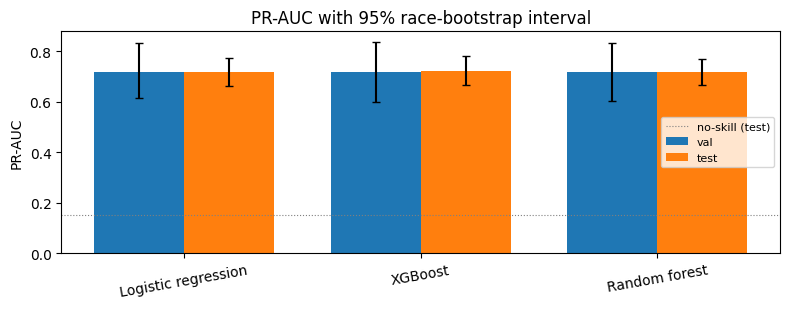

In [14]:
# PR-AUC with 95% race-bootstrap intervals, validation and test
ci_rows = []
for name, predict in REGISTRY.items():
    for sp in ["val", "test"]:
        d = SPLITS[sp]; p = predict(d); lo, hi = pr_auc_ci(d, p)
        ci_rows.append(dict(model=name, split=sp, pr_auc=average_precision_score(d[TARGET], p), ci_low=lo, ci_high=hi))
ci = pd.DataFrame(ci_rows); display(ci.pivot(index="model", columns="split", values=["pr_auc", "ci_low", "ci_high"]).round(4).loc[order_models])

fig, ax = plt.subplots(figsize=(8, 3.2)); w = 0.38
for j, sp in enumerate(["val", "test"]):
    c = ci[ci["split"] == sp].set_index("model").loc[order_models]
    ax.bar(np.arange(len(c)) + (j - 0.5) * w, c["pr_auc"], w, yerr=[c["pr_auc"] - c["ci_low"], c["ci_high"] - c["pr_auc"]], capsize=3, label=sp)
ax.set_xticks(range(len(order_models))); ax.set_xticklabels(order_models, rotation=10); ax.axhline(test[TARGET].mean(), color="grey", ls=":", lw=0.8, label="no-skill (test)")
ax.set_ylabel("PR-AUC"); ax.set_title("PR-AUC with 95% race-bootstrap interval"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

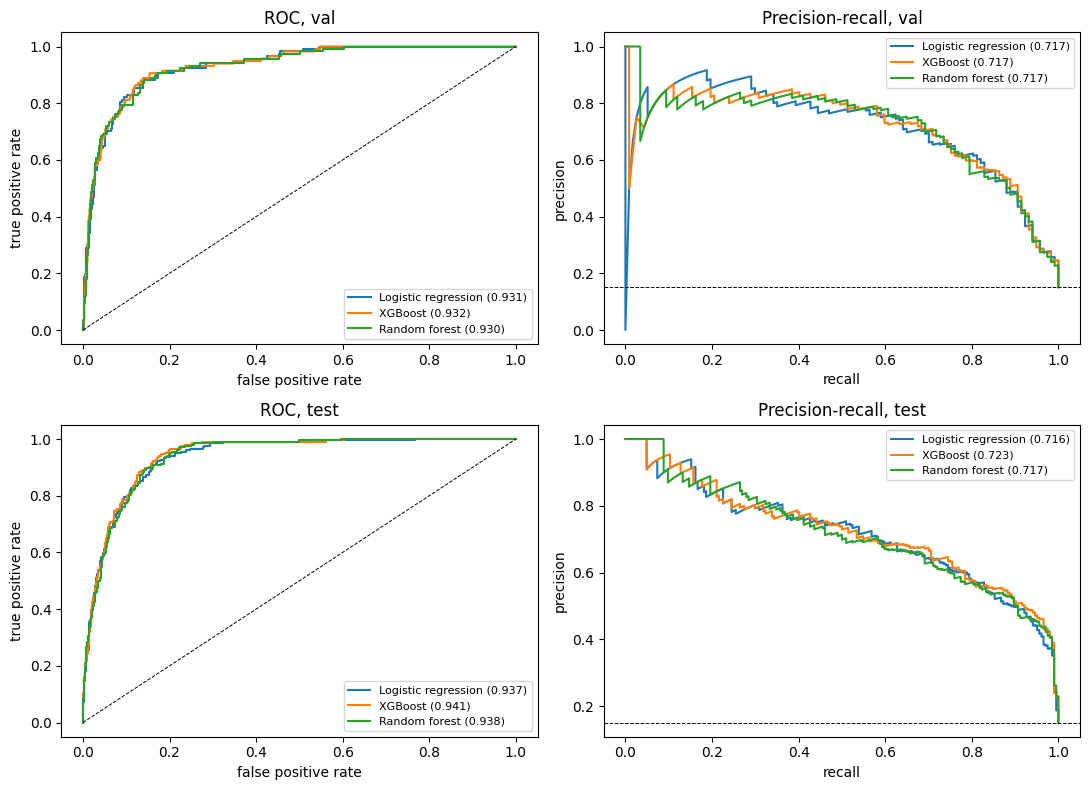

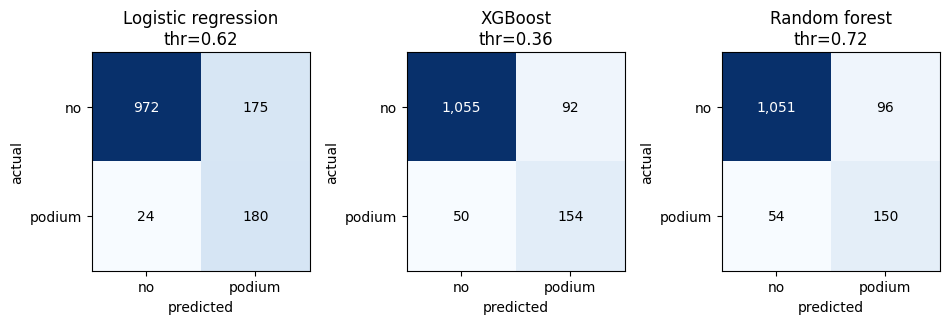

In [15]:
# ROC and precision-recall curves, validation (top) and test (bottom)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for r, sp in enumerate(["val", "test"]):
    d = SPLITS[sp]
    for name, predict in REGISTRY.items():
        p = predict(d); fpr, tpr, _ = roc_curve(d[TARGET], p); pr, rc, _ = precision_recall_curve(d[TARGET], p)
        axes[r, 0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(d[TARGET], p):.3f})")
        axes[r, 1].plot(rc, pr, label=f"{name} ({average_precision_score(d[TARGET], p):.3f})")
    axes[r, 0].plot([0, 1], [0, 1], "k--", lw=0.7); axes[r, 1].axhline(d[TARGET].mean(), color="k", ls="--", lw=0.7)
    axes[r, 0].set(title=f"ROC, {sp}", xlabel="false positive rate", ylabel="true positive rate")
    axes[r, 1].set(title=f"Precision-recall, {sp}", xlabel="recall", ylabel="precision")
    for a in axes[r]: a.legend(fontsize=8)
plt.tight_layout(); plt.show()

# confusion matrices on test at each model's validation-chosen threshold
fig, axes = plt.subplots(1, len(REGISTRY), figsize=(3.2 * len(REGISTRY), 3.2))
for ax, (name, predict) in zip(np.atleast_1d(axes), REGISTRY.items()):
    cm = confusion_matrix(test[TARGET], (predict(test) >= THRESHOLDS[name]).astype(int))
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm): ax.text(j, i, f"{v:,}", ha="center", va="center", color="white" if v > cm.max() / 2 else "black")
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["no", "podium"], yticklabels=["no", "podium"], title=f"{name}\nthr={THRESHOLDS[name]:.2f}", xlabel="predicted", ylabel="actual")
plt.tight_layout(); plt.show()

year,2020,2021,2022,2023,2024
model,,,,,
Logistic regression,0.707,0.728,0.703,0.775,0.647
XGBoost,0.677,0.771,0.682,0.771,0.686
Random forest,0.693,0.752,0.691,0.753,0.693


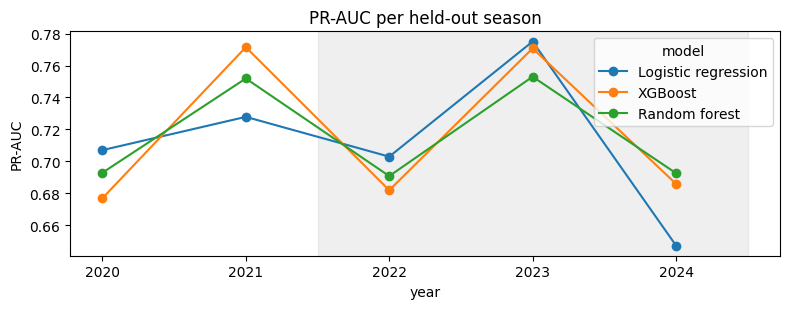

In [16]:
# stability: PR-AUC per held-out season (era sensitivity), validation + test seasons
per_season = []
for sp in ["val", "test"]:
    d = SPLITS[sp]
    for name, predict in REGISTRY.items():
        p = pd.Series(predict(d), index=d.index)
        for y, gy in d.groupby("year"):
            per_season.append(dict(model=name, year=int(y), split=sp, pr_auc=average_precision_score(gy[TARGET], p.loc[gy.index]), top3_precision=gy.assign(_p=p.loc[gy.index]).sort_values(["raceId", "_p"], ascending=[True, False]).groupby("raceId").head(3)[TARGET].mean()))
ps = pd.DataFrame(per_season)
display(ps.pivot(index="model", columns="year", values="pr_auc").loc[order_models].round(3))
ax = ps.pivot(index="year", columns="model", values="pr_auc")[order_models].plot(marker="o", figsize=(8, 3.2), title="PR-AUC per held-out season")
ax.axvspan(min(TEST_YEARS) - 0.5, max(TEST_YEARS) + 0.5, color="grey", alpha=0.12); ax.set_ylabel("PR-AUC"); ax.set_xticks(sorted(ps["year"].unique())); plt.tight_layout(); plt.show()

In [17]:
# Auto-written conclusions: every sentence below is computed from the tables above
v = table["val"]; t = table["test"]
best_v, best_t = v["pr_auc"].idxmax(), t["pr_auc"].idxmax()
print(f"Primary metric (PR-AUC): best on validation = {best_v} ({v['pr_auc'].max():.3f}); best on test = {best_t} ({t['pr_auc'].max():.3f}).")
print(f"Grid-only baseline: validation {base_val.loc['grid-only LR','pr_auc']:.3f}, test {test_base['pr_auc']:.3f}; no-skill test {test[TARGET].mean():.3f}.")
for name in order_models:
    lo, hi = ci[(ci.model == name) & (ci.split == "test")][["ci_low", "ci_high"]].iloc[0]
    gain = t.loc[name, "pr_auc"] - test_base["pr_auc"]
    print(f"- {name}: test PR-AUC {t.loc[name,'pr_auc']:.3f} [{lo:.3f}, {hi:.3f}] ({gain:+.3f} vs grid-only), ROC-AUC {t.loc[name,'roc_auc']:.3f}, F1 {t.loc[name,'f1']:.3f}; "
          f"train-val PR-AUC gap {gap_tbl.loc[name,'gap']:+.3f}; val->test PR-AUC change {t.loc[name,'pr_auc'] - v.loc[name,'pr_auc']:+.3f}.")
tops = ci[ci.split == "test"].set_index("model").loc[order_models]
best_row = tops.loc[best_t]
not_sep = [m for m in order_models if m != best_t and tops.loc[m, "pr_auc"] >= best_row["ci_low"]]
clear = [m for m in order_models if m != best_t and m not in not_sep]
print(f"Models whose test PR-AUC lies inside {best_t}'s 95% interval (not clearly different): {not_sep or 'none'}; clearly below: {clear or 'none'}.")
print("All models vs grid-only baseline, test PR-AUC point estimate above baseline:", {m: bool(tops.loc[m, 'pr_auc'] > test_base['pr_auc']) for m in order_models})

Primary metric (PR-AUC): best on validation = Random forest (0.717); best on test = XGBoost (0.723).
Grid-only baseline: validation 0.648, test 0.647; no-skill test 0.151.
- Logistic regression: test PR-AUC 0.716 [0.663, 0.775] (+0.069 vs grid-only), ROC-AUC 0.937, F1 0.644; train-val PR-AUC gap -0.142; val->test PR-AUC change -0.000.
- XGBoost: test PR-AUC 0.723 [0.667, 0.783] (+0.075 vs grid-only), ROC-AUC 0.941, F1 0.684; train-val PR-AUC gap -0.113; val->test PR-AUC change +0.006.
- Random forest: test PR-AUC 0.717 [0.665, 0.770] (+0.069 vs grid-only), ROC-AUC 0.938, F1 0.667; train-val PR-AUC gap -0.065; val->test PR-AUC change -0.001.
Models whose test PR-AUC lies inside XGBoost's 95% interval (not clearly different): ['Logistic regression', 'Random forest']; clearly below: none.
All models vs grid-only baseline, test PR-AUC point estimate above baseline: {'Logistic regression': True, 'XGBoost': True, 'Random forest': True}


### Reading the results (what to say in the report)
- **Metric choice.** PR-AUC is primary because podiums are rare and ranking matters; ROC-AUC is secondary; F1 depends on a threshold that was picked on validation and is reported for completeness.
- **Against the baseline.** A full model is only worth its complexity if its PR-AUC is clearly above the grid-only logistic regression (compare the intervals above, not just the point values). If a model is within the interval of the baseline, say so: grid position already carries most of the signal.
- **Linear vs trees.** If logistic regression is close to the tree models, the signal is mostly monotone (better grid, better car, better form → more podiums) and interactions add little. If the tree models are clearly ahead, interactions or non-linear effects matter.
- **Boosting vs bagging.** If random forest and XGBoost agree, the result does not depend on how the trees are combined.
- **Era shift.** Test seasons follow new regulations, so a drop from validation to test is expected. The per-season plot shows whether it is a single odd season or a level shift.

**Limitations (report).**
1. Validation (2 seasons, ~40 races) and test (3 seasons) are small; interval widths show how noisy the scores are.
2. The test era (2022–24) has different cars than most of the training years; form and standings features learned in earlier eras may transfer imperfectly.
3. Qualifying data is missing for early eras; models rely on missing-value handling (flags / native NaN) for those rows.
4. Team renames reset constructor form; retirements (reliability) are not modelled, so a podium-level car that breaks down is a miss no pre-race feature can predict.
5. Exactly three drivers podium per race, but the models score drivers independently; top-3 precision per race is reported to show the effect.
6. F1 at one global threshold treats every race alike; a per-race "pick the top 3" rule is a different decision rule.
7. Feature importance in later sections describes what the model uses, not what causes podiums.

## 13.9 Save and hand-off
Fitted models (trained on train only), thresholds, settings and the result tables are saved for the ablation, XAI and inference sections. The saved pipelines use the `QuantileClipper` class from 13.1, so any notebook that loads them with `joblib.load` must define that class first (or run in the same kernel). The neural-network section adds itself with
```python
REGISTRY["Shallow NN"] = lambda d: nn_predict_proba(d[FEATURES])   # returns P(podium) per row
THRESHOLDS["Shallow NN"] = best_f1_threshold(val[TARGET], REGISTRY["Shallow NN"](val))
res_all = score_table(SPLITS)                                       # same metrics, same splits
```

In [18]:
MODEL_DIR = OUT + "models/"; os.makedirs(MODEL_DIR, exist_ok=True)
for name, m in FINAL.items():
    joblib.dump(m, MODEL_DIR + name.lower().replace(" ", "_") + ".joblib")
json.dump(dict(thresholds=THRESHOLDS, params={k: {a: (b if isinstance(b, (int, float, str)) else str(b)) for a, b in v.items()} for k, v in FINAL_PARAMS.items()},
               final_attempt=FINAL_TAG, features=FEATURES, primary_metric="pr_auc", secondary_metric="roc_auc"),
          open(MODEL_DIR + "model_config.json", "w"), indent=2)
table.round(5).to_csv(MODEL_DIR + "model_comparison.csv")
pd.concat({k: v.drop(columns=[c for c in v.columns if c in ("cv_std",)]) for k, v in TRIALS.items()}).to_csv(MODEL_DIR + "tuning_trials.csv")

assert test[TARGET].notna().all() and set(res_all["split"]) == {"train", "val", "test"}
print("Saved to", MODEL_DIR, "->", sorted(os.listdir(MODEL_DIR)))
print("Handed on: FINAL (fitted pipelines), REGISTRY, THRESHOLDS, FINAL_PARAMS, table, TRIALS, metrics_at, best_f1_threshold, score_table")

Saved to clean/models/ -> ['logistic_regression.joblib', 'model_comparison.csv', 'model_config.json', 'random_forest.joblib', 'tuning_trials.csv', 'xgboost.joblib']
Handed on: FINAL (fitted pipelines), REGISTRY, THRESHOLDS, FINAL_PARAMS, table, TRIALS, metrics_at, best_f1_threshold, score_table
